In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import optimize as opt
import csv
from collections import Counter

from scipy.integrate import odeint



%matplotlib inline



**Defining functions:**

In [2]:
# Manual model functions and helper functions

def Manual_Sam_secnuc_model(t, m0, L0, M0, kn, nc, k2, n2, kp): #single step secondary nucleation, no fragmentation
    ## 9 parameters: m0, P0, M0, kn, nc, k2, n2, kp, koff
    P0 = M0 / L0
    mtot=m0+M0
    c=kn*m0**nc
    kap=np.sqrt(2.*k2*m0**n2*m0*kp)
    lam=np.sqrt(2.*c*kp)
##equ 54 in JCP paper 2
    Minf=mtot
    Cp=kp*P0/kap + M0*kp/(2.*m0*kp) + lam**2/2./kap**2  
    Cm=kp*P0/kap - M0*kp/(2.*m0*kp) - lam**2/2./kap**2
    kinf=kap*np.sqrt(2/n2/(n2+1)+2*lam**2/nc/kap**2+2*M0/n2/m0+(2*kp*P0/kap)**2)
    kbarinf=np.sqrt(kinf**2-4*Cp*Cm*kap**2)
    Bp=(kinf+kbarinf)/kap/2
    Bm=(kinf-kbarinf)/kap/2
    M_norm=1-(1-M0/Minf)*((Bp+Cp)*(Bm+Cp*np.exp(kap*t))/(Bp+Cp*np.exp(kap*t))/(Bm+Cp))**(kinf**2/kbarinf/kap)*np.exp(-kinf*t) #normalised aggregate mass concentration
    return M_norm


def Manual_new_full_model(t, m0, L0, M0, kn, nc, k2, n2, kp, km, KE, KP, KS, cd, KIE, KIP, KIS, KIM): #the general function that has all processes, with saturation, and all inhibition mechanisms
    '''
    Function to calculate the normalised aggregate mass concentration at time t, given the parameters of the model.
    This function is the base for all models that have all processes, with saturation, and all inhibition mechanisms.
    It's parameters are:
    m0: initial monomer concentration
    P0: initial fibril number concentration
    M0: initial fibril mass concentration
    kn: rate constant for primary nucleation
    nc: exponent for primary nucleation
    k2: rate constant for secondary nucleation
    n2: exponent for secondary nucleation
    kp: rate constant for elongation
    km: rate constant for fragmentation
    KE: elongation saturation constant
    KP: primary nucleation saturation constant
    KS: secondary nucleation saturation constant
    cd: concentration of the inhibitor
    KIE: elongation inhibition constant
    KIP: primary nucleation inhibition constant
    KIS: secondary nucleation inhibition constant
    KIM: monomer inhibition constant
    '''
    ## 17 parameters: m0, P0, M0, kn, nc, k2, n2, kp, km, KE, KP, KS, cd, KIE, KIP, KIS, KIM
    P0 = M0 / L0
    mtot=m0+M0
    delta0=M0/m0
    kp=kp/(1+cd/KIM)
    kn=kn/(1+cd/KIM)**nc
    k2=k2/(1+cd/KIM)**n2
    KE=KE*(1+cd/KIM)
    KP=KP*(1+cd/KIM)
    KS=KS*(1+cd/KIM)
    kappa=np.sqrt(2*kp*mtot*(km+(k2*mtot**n2)/(1+(mtot/KS)**n2+cd/KIS))/(1+mtot/KE+cd/KIE))
    epsilon=(kn*mtot**nc/(1+(mtot/KP)**nc+cd/KIP))/(2*km*mtot+2*k2*mtot**(n2+1)/(1+(mtot/KS)**n2+cd/KIS))
    kappa0=np.sqrt(2*kp*m0*(km+(k2*m0**n2)/(1+(m0/KS)**n2+cd/KIS))/(1+m0/KE+cd/KIE))
    epsilon0=(kn*m0**nc/(1+(m0/KP)**nc+cd/KIP))/(2*km*m0+(2*k2*m0**(n2+1))/(1+(m0/KS)**n2+cd/KIS))
    n2p=(((k2*mtot**n2/(1+(mtot/KS)**n2+cd/KIS))/(km+(k2*mtot**n2/(1+(mtot/KS)**n2+cd/KIS))))*(n2*(1+cd/KIS)/(1+(mtot/KS)** n2+cd/KIS)))-((2*mtot/KE)/(1+mtot/KE+cd/KIE))
    p0=2*kp*P0 /(kappa0*(1+m0/KE+cd/KIE))
    c=3/(2*n2p+1)
    a1=kappa*t*(kappa*t <100) + 100*(kappa*t>=100) # to avoid overflow in exp
    mt=m0*(1+(p0/(2*c))*(kappa0/kappa)*(np.exp(a1)-np.exp(-a1))+(kappa0**2/kappa**2)*(epsilon0/c+delta0/(2*c)+(p0 ** 2/(2*c**2))*(1+(c*m0/KE)/(1+m0/KE+cd/KIE)))*(np.exp(a1)+np.exp(-a1)-2))**(-c)
    return (mtot-mt)/mtot


def col_name_to_dict(col_name, verbose = False):
    """
    Convert a column name of the form 'blahblah_m0:0.1_M0:0.2_L0:0.3' to a dictionary of parameter values.
    """
    name_parts = col_name.split('_')
    name_parts_dict = {}
    if verbose:
        print(f"Processing column: {col_name}")
    for i in name_parts:
        para_name = i.split(':')[0]
        if para_name in ['m0', 'M0', 'L0']:
            para_value_with_units = i.split(':')[1].strip(' X').strip(' Y')
            # remove any units from the parameter value (e.g., '1e-6uM' -> '1e-6') by retaining only the numeric part
            para_value = ''
            for c in para_value_with_units:
                if c.isdigit() or c == '.' or c == 'e' or c == '-':
                    para_value += c
                else: # stop as soon as we hit a non-numeric character (like a unit)
                    break
            name_parts_dict[para_name] = float(para_value)
            if verbose:
                print(f"Extracted {para_name}: {name_parts_dict[para_name]}")
        else: # raise an error if the parameter name is not recognized
            print(f"Unrecognized parameter name '{para_name}' in column '{col_name}'.")
    return name_parts_dict



def read_csv_no_duplicate_columns(path, **kwargs):
    sep = kwargs.get("sep", ",")

    with open(path, newline="", encoding=kwargs.get("encoding", "utf-8")) as f:
        reader = csv.reader(f, delimiter=sep)
        header = next(reader)

    duplicates = [name for name, count in Counter(header).items() if count > 1]

    if duplicates:
        raise ValueError(f"{len(duplicates)} duplicate column name(s) found: {', '.join(duplicates)}")

    return pd.read_csv(path, **kwargs)
          
def basinhopping_minimiser_rescalied_parameters(X, y, model, initial_guess, niter=100, T=1.0, stepsize=0.5):
    """
    Perform basinhopping minimization to fit the model to the data.
    
    Parameters:
    - X: Independent variable data (e.g., time points)
    - y: Dependent variable data (e.g., observed values)
    - model: The model function to fit
    - initial_guess: Initial guess for the parameters
    - niter: Number of iterations for basinhopping
    - T: Temperature parameter for basinhopping
    - stepsize: Step size for basinhopping
    
    Returns:
    - result: The result of the optimization containing the best-fit parameters
    """
    
    # Define the objective function to minimize (sum of squared residuals)
    def objective_function(params, initial_guess):
        params_rescaled = params * initial_guess
        try:
            prediction = model(X, *params_rescaled)
        except Exception:
            return 1e12
        if prediction.shape != y.shape or not np.all(np.isfinite(prediction)):
            return 1e12
        return np.sum((y - prediction) ** 2)

    # Perform basinhopping optimization
    minimizer_kwargs = {"method": "Nelder-Mead", "args": initial_guess}
    result = opt.basinhopping(objective_function, np.ones_like(initial_guess), niter=niter, T=T, stepsize=stepsize, minimizer_kwargs=minimizer_kwargs)
    
    return result


def ODE_builder(rhs, param_names, y0=None, observe=None, odeint_kwargs=None):
    """
    Turn an ODE specification into a model with the standard model(X, *params)
    fitting interface, integrating once per curve.

        rhs(M, t, params, m0, L0, M0) -> dM/dt
            `params` is the tuple of fit parameters (in `param_names` order).
            For a system, M and the return are vectors.
        param_names : ordered names of the fit parameters.
        y0(params, m0, L0, M0) -> initial state   (default: M0)
        observe(sol) -> 1-D measured quantity, sol has shape (n_times, n_states)
                        (default: first state)
        odeint_kwargs : passed through to scipy.integrate.odeint.
    """
    if y0 is None:
        y0 = lambda params, m0, L0, M0: M0
    if observe is None:
        observe = lambda sol: sol[:, 0]
    kw = {'mxstep': 500, 'atol': 1e-12, 'rtol': 1e-9}
    kw.update(odeint_kwargs or {})

    def model(X, *params):
        times, m0, L0, M0, groups = X
        times  = np.asarray(times, dtype=float)
        groups = np.rint(np.asarray(groups)).astype(int)   # curve_fit floats this row
        y_pred = np.empty(times.shape[0], dtype=float)

        for g in np.unique(groups):
            idx = np.flatnonzero(groups == g)
            g_m0, g_L0, g_M0 = float(m0[idx[0]]), float(L0[idx[0]]), float(M0[idx[0]])
            t_unique, inverse = np.unique(times[idx], return_inverse=True)

            f   = lambda M, t: rhs(M, t, params, g_m0, g_L0, g_M0)
            ic  = y0(params, g_m0, g_L0, g_M0)

            if t_unique[0] > 0.0:          # integrate from the IC time (t=0), then drop it
                sol = odeint(f, ic, np.concatenate(([0.0], t_unique)), **kw)[1:]
            else:                          # data already starts at t=0
                sol = odeint(f, ic, t_unique, **kw)

            y_pred[idx] = observe(sol)[inverse]   # scatter back to original order

        return y_pred

    model.param_names = list(param_names)   # metadata so run_fitting can introspect it
    return model

def _model_param_info(model):
    if hasattr(model, 'param_names'):          # built by ODE_builder
        names = list(model.param_names)
        return len(names), names
    n = model.__code__.co_argcount - 1         # plain function: count args after X
    return n, list(model.__code__.co_varnames[1:1 + n])

In [3]:
# ML derived model fucntions

def ML_model_no_inhib_OPUS_clean_data_2026_06_18(X, c0, c1, c2, c3, c4, c5):
    '''
    Function to calculate the normalised aggregate mass concentration at time t.
    For simplicity in the fitting, all known parameters are included in the input X, and the function is defined as a function of the unknown parameters c0, c1,...
    '''
    t, m0, L0, M0, groups  = X  # groups unused, kept for the uniform interface
    M_norm=c3 * (1 - np.exp(-c0**2 * m0**c1 * t**np.exp(c2) * np.exp(c4*M0))) + c5
    return M_norm

def ML_model_no_inhib_OPUS_clean_data_2026_06_18_rewritten_for_overflow_avoidance(X, c0, c1, c2, c3, c4, c5):
    '''
    Function to calculate the normalised aggregate mass concentration at time t.
    For simplicity in the fitting, all known parameters are included in the input X, and the function is defined as a function of the unknown parameters c0, c1,...
    '''
    t, m0, L0, M0, groups = X  # groups unused, kept for the uniform interface
    # threshold to avoid overflow in exp
    mask = np.exp(c0) * m0**c1 * t**np.exp(c2) * np.exp(c4*M0) > 100  # threshold to avoid overflow in exp
    M_norm = np.where(mask, c3 + c5, c3 * (1 - np.exp(-np.exp(c0) * m0**c1 * t**np.exp(c2) * np.exp(c4*M0))) + c5)
    return M_norm

def ODE_test_RHS(M, t, params, m0, L0, M0):
    return params*M

ODE_test = ODE_builder(
    ODE_test_RHS,
    param_names=['k'],
    y0=lambda params, m0, L0, M0: M0, 
)

def ML_model_no_inhib_OPUS_clean_data_2026_06_18_ODE_rhs(M, t, params, m0, L0, M0):
    c0, c1, c2, c3, c4, c5 = params
    return (c3 - M) * (c0 * (1 + c4 * m0 + c5 * M0) + (c1 + c2 * M) * M)

ML_model_no_inhib_OPUS_clean_data_2026_06_18_ODE = ODE_builder(
    ML_model_no_inhib_OPUS_clean_data_2026_06_18_ODE_rhs,
    param_names=['c0', 'c1', 'c2', 'c3', 'c4', 'c5'],
    y0=lambda params, m0, L0, M0: M0, 
)


def ML_checkpoint_24_normalized_time_ODE_rhs(concentration, tau, params, m0, L0, M0):
    """
    RHS copied from checkpoint_24/best_program.py, evaluated numerically.

    tau is the benchmark-style normalized time coordinate x0. m0 is x1,
    M0 is x2, and concentration is the dynamic ODE state x3.
    L0 is accepted only to keep the notebook's uniform fitting interface.
    """
    c0, c1, c2, c3, c4, c5, c6, c7, c8 = params
    monomer = m0
    seed = M0
    concentration = float(np.asarray(concentration).reshape(-1)[0])

    plateau = c7
    capacity = plateau - concentration
    gate = (1 + np.tanh(c8 ** 2 * (concentration + c6 ** 2 * seed - c5))) / 2

    primary = c0 ** 2 * monomer ** c1
    elongation = c2 ** 2 * concentration
    secondary = c3 ** 2 * monomer ** c4 * concentration * gate
    growth = primary + elongation + secondary
    return capacity * growth


def ML_checkpoint_24_normalized_time_ODE(X, c0, c1, c2, c3, c4, c5, c6, c7, c8):
    """
    Numerically integrate checkpoint_24's discovered ODE for each curve.

    The benchmark that produced this model used normalized time x0 in [0, 1],
    raw m0 as x1, raw M0 as x2, and the current normalized concentration as x3.
    This wrapper preserves that convention by normalizing time within each curve
    before calling scipy.integrate.odeint.
    """
    times, m0, L0, M0, groups = X
    times = np.asarray(times, dtype=float)
    m0 = np.asarray(m0, dtype=float)
    L0 = np.asarray(L0, dtype=float)
    M0 = np.asarray(M0, dtype=float)
    groups = np.rint(np.asarray(groups)).astype(int)
    params = (c0, c1, c2, c3, c4, c5, c6, c7, c8)
    y_pred = np.empty(times.shape[0], dtype=float)

    for g in np.unique(groups):
        idx = np.flatnonzero(groups == g)
        g_t = times[idx]
        g_m0 = float(m0[idx[0]])
        g_L0 = float(L0[idx[0]])
        g_M0 = float(M0[idx[0]])

        t_span = float(np.max(g_t) - np.min(g_t))
        if t_span <= 0:
            tau = np.zeros_like(g_t, dtype=float)
        else:
            tau = (g_t - np.min(g_t)) / t_span

        # Manual_Sam_secnuc_model returns normalized aggregate mass M/(m0+M0),
        # so the physical initial normalized state is M0/(m0+M0).
        initial_state = g_M0 / (g_m0 + g_M0) if (g_m0 + g_M0) > 0 else 0.0
        tau_unique, inverse = np.unique(tau, return_inverse=True)
        tau_eval = tau_unique if tau_unique[0] == 0.0 else np.concatenate(([0.0], tau_unique))

        try:
            sol = odeint(
                lambda y, tt: ML_checkpoint_24_normalized_time_ODE_rhs(y, tt, params, g_m0, g_L0, g_M0),
                [initial_state],
                tau_eval,
                mxstep=500,
                atol=1e-12,
                rtol=1e-9,
            ).reshape(-1)
            if tau_unique[0] != 0.0:
                sol = sol[1:]
            y_pred[idx] = sol[inverse]
        except Exception:
            y_pred[idx] = np.nan

    return y_pred

ML_checkpoint_24_normalized_time_ODE.param_names = ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8']


def ML_model_no_inhib_initial(X, c1, c2, c3, c4):
    '''
    Function to calculate the normalised aggregate mass concentration at time t.
    For simplicity in the fitting, all known parameters are included in the input X, and the function is defined as a function of the unknown parameters c0, c1,...
    '''
    t, m0, L0, M0, groups = X  # groups unused, kept for the uniform interface
    M_norm=(1+ np.exp(c1 - c2*t-c3*m0))**(-c4) 
    return M_norm


def ML_model_no_inhib_initial_nonorm(X, c0, c1, c2, c3, c4, c5):
    '''
    Function to calculate the UNnormalised aggregate mass concentration at time t.
    For simplicity in the fitting, all known parameters are included in the input X, and the function is defined as a function of the unknown parameters c0, c1,...
    '''
    t, m0, L0, M0, groups = X  # groups unused, kept for the uniform interface
    M=c0*(1+ np.exp(c1 - c2*t-c3*m0))**(-c4) + c5
    return M


## plotting comparison of models ##

### generate artificial data and save

In [4]:
# Define the parameters m0, L0, M0, kn, nc, k2, n2, kp
# The known parameters m0, L0 and M0 need to be lists, but can be length 1
parameters = [[1e-6, 3e-6, 8e-6], [1000], [0, 1e-8, 1e-7], 1, 2, 1e10, 2, 3e7]  # Example
parameters = [[1e-6, 3e-6], [1000], [0], 1, 2, 1e10, 2, 3e7]  # Example

tmax = 20  # Maximum time for the simulation
N_timepoints = 30  # Number of time points to simulate
output_name = 'manual_model_data.tsv'  # Output CSV file name

if len(parameters) != 8:
    raise ValueError(
        f"`parameters` must contain 8 items [m0_values, L0_values, M0_values, kn, nc, k2, n2, kp], got {len(parameters)}."
    )

m0_values, L0_values, M0_values, kn, nc, k2, n2, kp = parameters
m0_values = np.atleast_1d(np.asarray(m0_values, dtype=float))
M0_values = np.atleast_1d(np.asarray(M0_values, dtype=float))
L0_values = np.atleast_1d(np.asarray(L0_values, dtype=float))



if m0_values.size == 0:
    raise ValueError("`m0_values` must contain at least one value.")
if np.any(m0_values <= 0):
    raise ValueError("All `m0_values` must be > 0.")

# Build one combined dataset across all m0 values
t_data = np.linspace(0, tmax, N_timepoints)

all_data = {}
for m0_i in m0_values:
    for M0 in M0_values:
        for L0 in L0_values:
            name = f'm0:{m0_i}_M0:{M0}_L0:{L0}'
            print(f'Generating {name}')
            y_i = Manual_Sam_secnuc_model(t_data, m0_i, L0, M0, kn, nc, k2, n2, kp)
            all_data[name+' X'] = t_data
            all_data[name+' Y'] = y_i


all_data_df = pd.DataFrame(all_data)
all_data_df.to_csv(output_name, index=False, sep='\t')

Generating m0:1e-06_M0:0.0_L0:1000.0
Generating m0:3e-06_M0:0.0_L0:1000.0


### load data and produce fits

In [5]:
# define functions
def run_fitting(ML_model, initial_guess, data_location, separator,
                minimisation_method='basinhopping', niter=100):
    expected_params, model_param_names = _model_param_info(ML_model)
    if len(initial_guess) != expected_params:
        raise ValueError(f"Initial guess has {len(initial_guess)} parameters, "
                         f"but {expected_params} are expected.")

    data_df = read_csv_no_duplicate_columns(data_location, sep=separator)

    all_t, all_m0, all_y, all_M0, all_L0, all_groups = [], [], [], [], [], []
    curve_idx = 0
    for col in data_df.columns:
        name_parts_dict = col_name_to_dict(col)
        if 'X' in col:
            all_t.append(data_df[col].values[~np.isnan(data_df[col].values)])
        elif 'Y' in col:
            vals = data_df[col].values
            mask = ~np.isnan(vals)
            y = vals[mask]
            all_y.append(y)
            all_m0.append(np.full_like(y, name_parts_dict['m0'], dtype=float))
            all_M0.append(np.full_like(y, name_parts_dict['M0'], dtype=float))
            all_L0.append(np.full_like(y, name_parts_dict['L0'], dtype=float))
            all_groups.append(np.full(y.shape, curve_idx, dtype=int))
            curve_idx += 1
        else:
            raise ValueError(f"Column name {col} does not contain 'X' or 'Y'.")

    all_t      = np.concatenate(all_t)
    all_m0     = np.concatenate(all_m0)
    all_y      = np.concatenate(all_y)
    all_M0     = np.concatenate(all_M0)
    all_L0     = np.concatenate(all_L0)
    all_groups = np.concatenate(all_groups)

    for arr_name, arr in zip(['all_t', 'all_m0', 'all_y', 'all_M0', 'all_L0'],
                             [all_t, all_m0, all_y, all_M0, all_L0]):
        if np.any(np.isnan(arr)):
            raise ValueError(f"{arr_name} contains NaN values.")
        if np.any(np.isinf(arr)):
            raise ValueError(f"{arr_name} contains infinite values.")

    X = (all_t, all_m0, all_L0, all_M0, all_groups)   # bundle once; groups rides along

    if minimisation_method == 'curve_fit':
        popt, pcov, infodict, msg, _ = opt.curve_fit(
            ML_model, X, all_y, p0=initial_guess,
            maxfev=40000, full_output=True, method='lm')
        err = np.sum(infodict['fvec'] ** 2)

    elif minimisation_method == 'basinhopping':
        out = basinhopping_minimiser_rescalied_parameters(
            X, all_y, ML_model, initial_guess, niter=niter, T=1.0, stepsize=0.5)
        popt = out.x * initial_guess
        err = out['fun']

    else:
        raise ValueError(f"Unknown minimisation method: {minimisation_method}. "
                         f"Choose 'curve_fit' or 'basinhopping'.")

    param_names = model_param_names[:len(popt)]
    return popt, err, param_names, data_df


def run_fitting_old(ML_model, initial_guess, data_location, separator, minimisation_method='basinhopping', niter=100):
    # check that initial_guess has the correct length
    expected_params = ML_model.__code__.co_argcount - 1  # Subtract 1 for X
    if len(initial_guess) != expected_params:
        raise ValueError(f"Initial guess has {len(initial_guess)} parameters, but {expected_params} are expected.")
    
    # Load the data from the CSV file and raise an error if two columns have the same name
    data_df = read_csv_no_duplicate_columns(data_location,sep=separator)

    # build a list of all the t, m0, y, L0 and M0 values from the column names and values
    all_t, all_m0, all_y, all_M0, all_L0 = [], [], [], [], []
    for col in data_df.columns:
        name_parts_dict = col_name_to_dict(col)
        if 'X' in col:
            all_t.append(data_df[col].values[~np.isnan(data_df[col].values)]) # excluding nan values
        elif 'Y' in col:
            all_y.append(data_df[col].values[~np.isnan(data_df[col].values)])
            all_m0.append(np.full_like(data_df[col].values[~np.isnan(data_df[col].values)], name_parts_dict['m0'], dtype=float))
            all_M0.append(np.full_like(data_df[col].values[~np.isnan(data_df[col].values)], name_parts_dict['M0'], dtype=float))
            all_L0.append(np.full_like(data_df[col].values[~np.isnan(data_df[col].values)], name_parts_dict['L0'], dtype=float))
        else:
            raise ValueError(f"Column name {col} does not contain 'X' or 'Y'.")

    all_t = np.concatenate(all_t)
    all_m0 = np.concatenate(all_m0)
    all_y = np.concatenate(all_y)
    all_M0 = np.concatenate(all_M0)
    all_L0 = np.concatenate(all_L0)
    # check if any of the arrays contain infs or nans
    for arr_name, arr in zip(['all_t', 'all_m0', 'all_y', 'all_M0', 'all_L0'], [all_t, all_m0, all_y, all_M0, all_L0]):
        if np.any(np.isnan(arr)):
            raise ValueError(f"{arr_name} contains NaN values.")
        if np.any(np.isinf(arr)):
            raise ValueError(f"{arr_name} contains infinite values.")

    ## curve_fit is much faster but struggles with convergence more
    if minimisation_method == 'curve_fit':
        popt, pcov, infodict, msg,_ = opt.curve_fit(
            ML_model,
            (all_t, all_m0, all_L0, all_M0),
            all_y,
            p0=initial_guess,
            maxfev=40000,
            full_output = True,
            method = 'lm'
        )
        err = np.sum(infodict['fvec']**2)


    elif minimisation_method == 'basinhopping':
        out = basinhopping_minimiser_rescalied_parameters((all_t, all_m0, all_L0, all_M0), all_y, ML_model, initial_guess, niter=100, T=1.0, stepsize=0.5)
        popt = out.x * initial_guess  # Rescale the parameters back to their original scale
        err = out['fun']

    else:
        raise ValueError(f"Unknown minimisation method: {minimisation_method}. Choose 'curve_fit' or 'basinhopping'.")
    
    param_names = ML_model.__code__.co_varnames[1:1 + len(popt)]  # Skip the first argument (X)
    
    return popt, err, param_names, data_df

def plot_global_fit(data_df, ML_model, popt, save_path=None):
    """
    Plot the global fit of the ML model against the data.
    
    Parameters:
    - data_df: DataFrame containing the data
    - ML_model: The model function used for fitting
    - popt: Fitted parameters
    - save_path: Path to save the plot (optional)
    """

    fig, ax = plt.subplots(figsize=(9, 6))

    conditions = [i.strip(' Y') for i in data_df.columns if 'Y' in i]
    for cond in conditions:
        t_raw = data_df[cond + ' X'].values
        y_raw = data_df[cond + ' Y'].values
        mask  = ~(np.isnan(t_raw) | np.isnan(y_raw))      # drop padded rows
        t_i, y_i = t_raw[mask], y_raw[mask]

        name_parts_dict = col_name_to_dict(cond)
        m0 = float(name_parts_dict['m0'])
        M0 = float(name_parts_dict['M0'])
        L0 = float(name_parts_dict['L0'])

        # dense grid for a smooth fit line; single curve => one group of zeros
        t_grid = np.linspace(t_i.min(), t_i.max(), 300)
        X_grid = (t_grid,
                  np.full_like(t_grid, m0),
                  np.full_like(t_grid, L0),
                  np.full_like(t_grid, M0),
                  np.zeros_like(t_grid, dtype=int))
        y_fit_i = ML_model(X_grid, *popt)

        sc = ax.scatter(t_i, y_i, s=18, alpha=0.6, label=cond)
        ax.plot(t_grid, y_fit_i, linewidth=2.0, color=sc.get_facecolor()[0])

    ax.set_xlabel("Time")
    ax.set_ylabel("Normalized aggregate mass concentration")
    ax.set_title(f"Global fit of {getattr(ML_model, '__name__', 'model')}")
    ax.legend(ncol=2, fontsize=9)
    fig.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    else:
        plt.show()


def plot_manual_vs_ml_by_configuration(data_df, ML_model, popt, save_prefix=None):
    """Create one figure per condition with manual data and ML ODE prediction overlaid."""
    conditions = [i.strip(' Y') for i in data_df.columns if 'Y' in i]

    for cond in conditions:
        t_raw = data_df[cond + ' X'].values
        y_raw = data_df[cond + ' Y'].values
        mask = ~(np.isnan(t_raw) | np.isnan(y_raw))
        t_i, y_i = t_raw[mask], y_raw[mask]

        name_parts_dict = col_name_to_dict(cond)
        m0 = float(name_parts_dict['m0'])
        M0 = float(name_parts_dict['M0'])
        L0 = float(name_parts_dict['L0'])

        t_grid = np.linspace(t_i.min(), t_i.max(), 300)
        X_grid = (t_grid,
                  np.full_like(t_grid, m0),
                  np.full_like(t_grid, L0),
                  np.full_like(t_grid, M0),
                  np.zeros_like(t_grid, dtype=int))
        y_ml = ML_model(X_grid, *popt)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.scatter(t_i, y_i, s=28, alpha=0.75, label="Manual model data", color="tab:blue")
        ax.plot(t_grid, y_ml, linewidth=2.5, label="ML checkpoint-24 ODE fit", color="tab:orange")
        ax.set_xlabel("Time")
        ax.set_ylabel("Normalized aggregate mass concentration")
        ax.set_title(f"Manual vs ML fit: m0={m0:g}, M0={M0:g}, L0={L0:g}")
        ax.legend()
        fig.tight_layout()

        if save_prefix:
            safe_cond = cond.replace(':', '-').replace('.', 'p').replace(' ', '_')
            fig.savefig(f"{save_prefix}_{safe_cond}.png", dpi=300)
        else:
            plt.show()

Least squares error: 4.785163726799501
Fitted parameters:
c0: 4.65e+00
c1: 5.29e-01
c2: -2.83e-03
c3: 9.20e+00
c4: 1.41e+01
c5: -1.42e-01
c6: -3.37e+01
c7: 5.59e+01
c8: 7.61e+01


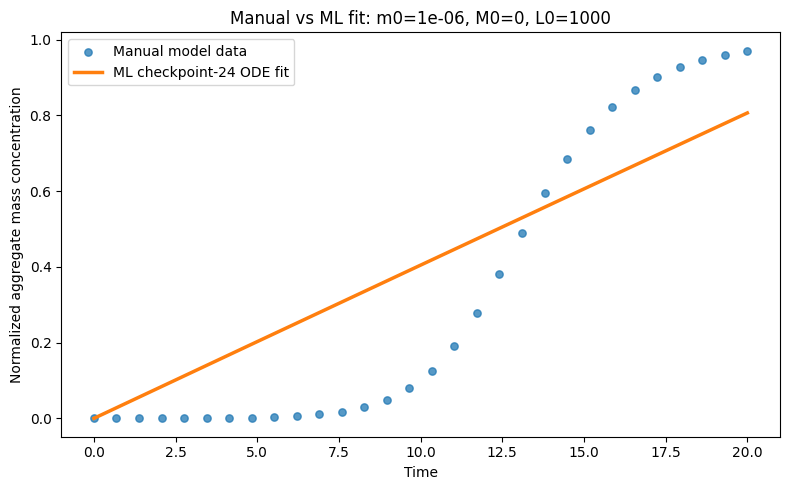

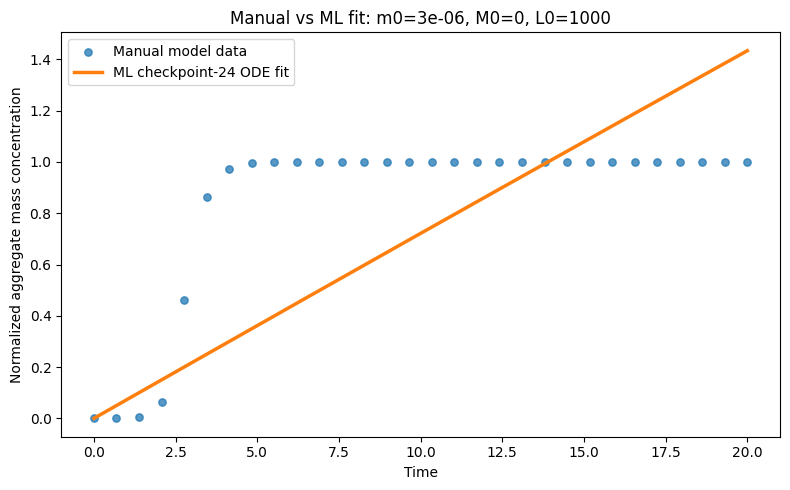

In [6]:
# run fit and plot

ML_model = ML_checkpoint_24_normalized_time_ODE

# These are the starting values supplied in checkpoint_24/best_program.py.
# The optimizer changes only these constants c0..c8; m0, M0, L0, time, and
# the ODE initial state are fixed by each curve's data/header metadata.
initial_guess = np.array([0.3, 0.5, 0.5, 0.8, 0.5, 0.3, 0.5, 1.0, 2.0])

data_location = "manual_model_data.tsv"  # Change this to the path of your data file
separator = '\t'  # Change this to the appropriate separator for your CSV file

popt, err, param_names, data_df = run_fitting(ML_model, initial_guess, data_location, separator, minimisation_method='basinhopping', niter=10)

print(f"Least squares error: {err}")
print("Fitted parameters:\n" + "\n".join(f"{name}: {value:.2e}" for name, value in zip(param_names, popt)))
plot_manual_vs_ml_by_configuration(data_df, ML_model, popt)


/tmp/ipykernel_27933/2003587526.py:13: RuntimeWarning: invalid value encountered in scalar power
  capacity_term = capacity ** (1 + c8 ** 2)
/tmp/ipykernel_27933/2003587526.py:50: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = odeint(
/tmp/ipykernel_27933/2003587526.py:17: RuntimeWarning: overflow encountered in scalar power
  secondary = c3 ** 2 * monomer ** c4 * concentration ** (1 + c5 ** 2)
/tmp/ipykernel_27933/2003587526.py:50: ODEintWarning: Illegal input detected (internal error). Run with full_output = 1 to get quantitative information.
  sol = odeint(
/tmp/ipykernel_27933/2003587526.py:17: RuntimeWarning: invalid value encountered in scalar multiply
  secondary = c3 ** 2 * monomer ** c4 * concentration ** (1 + c5 ** 2)
/tmp/ipykernel_27933/2003587526.py:17: RuntimeWarning: overflow encountered in scalar multiply
  secondary = c3 ** 2 * monomer ** c4 * concentration ** (1 + c5 ** 2)


Checkpoint 9 basinhopping scaled residual loss: 0.010596908345682405
Checkpoint 9 fitted parameters:
c0: 3.82e+04
c1: 1.72e+00
c2: 1.36e-01
c3: -7.08e+03
c4: 1.06e+00
c5: 6.80e-01
c6: 2.90e+00
c7: 9.99e-01
c8: 3.70e-01


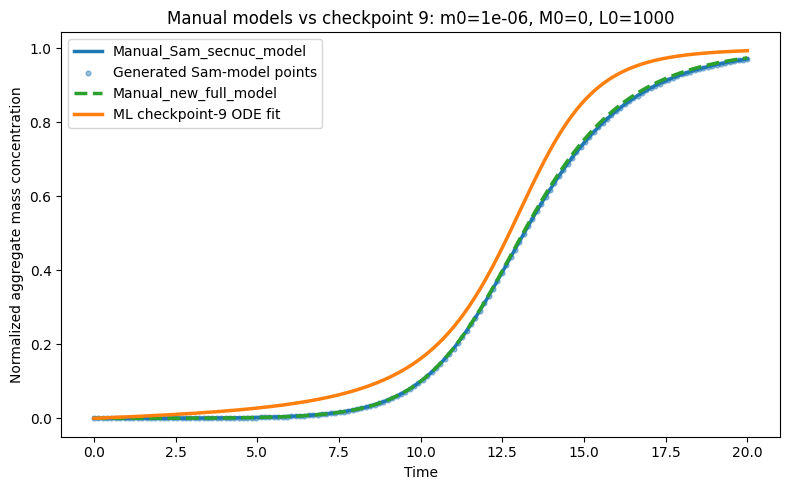

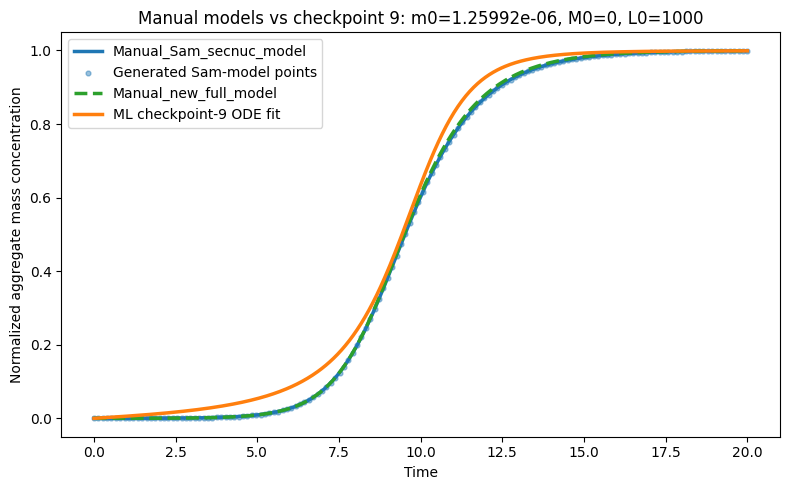

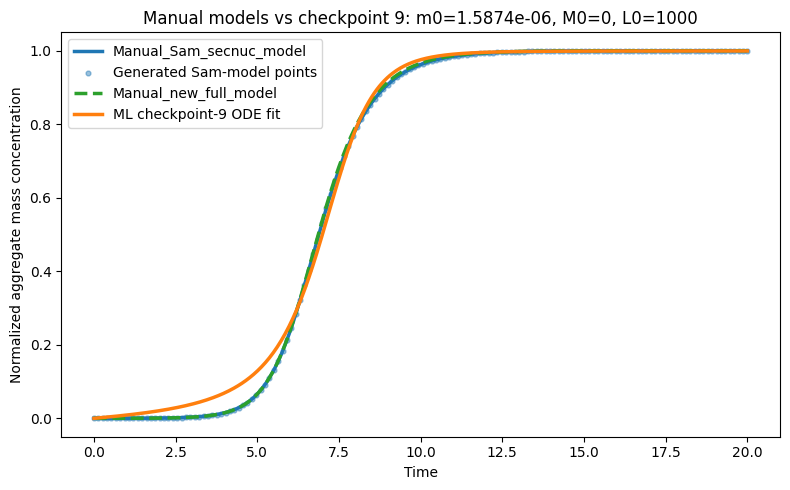

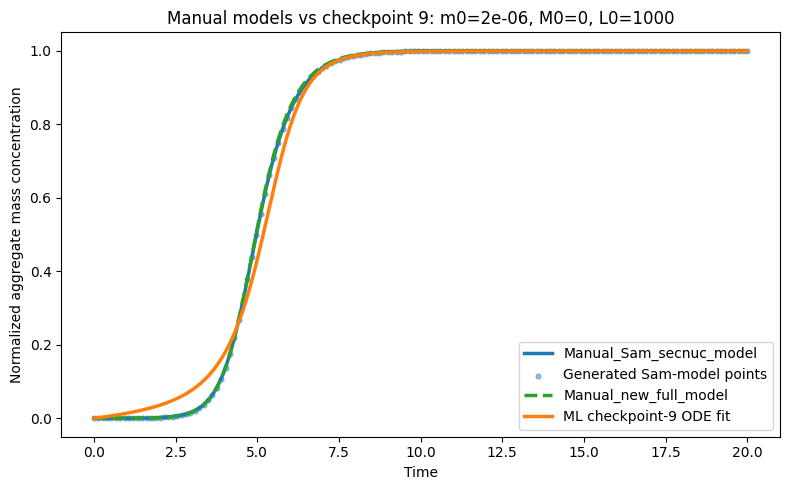

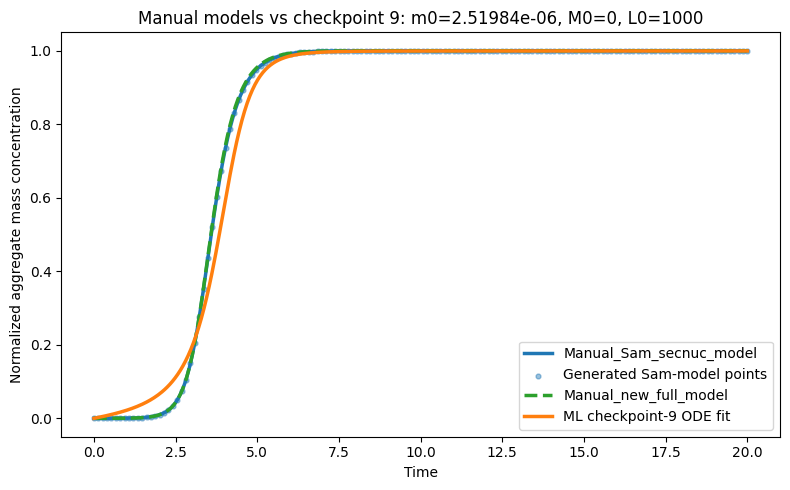

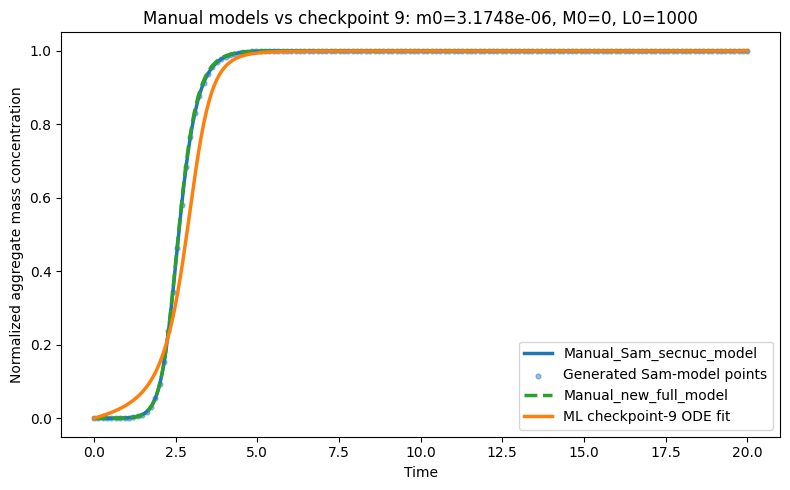

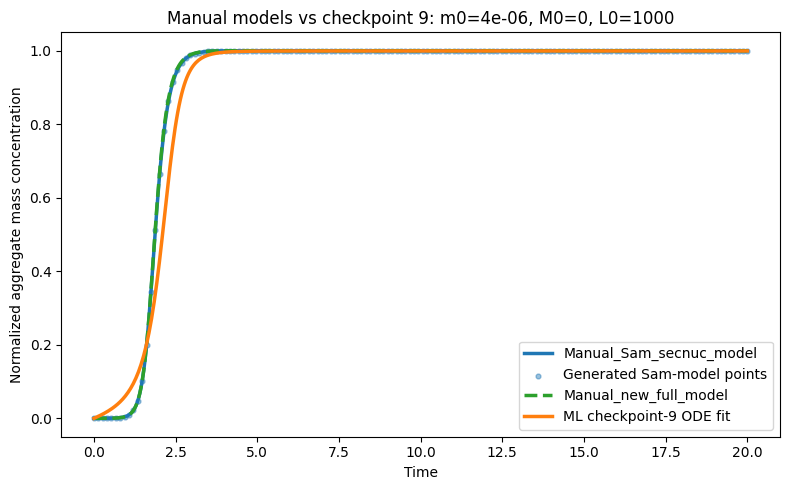

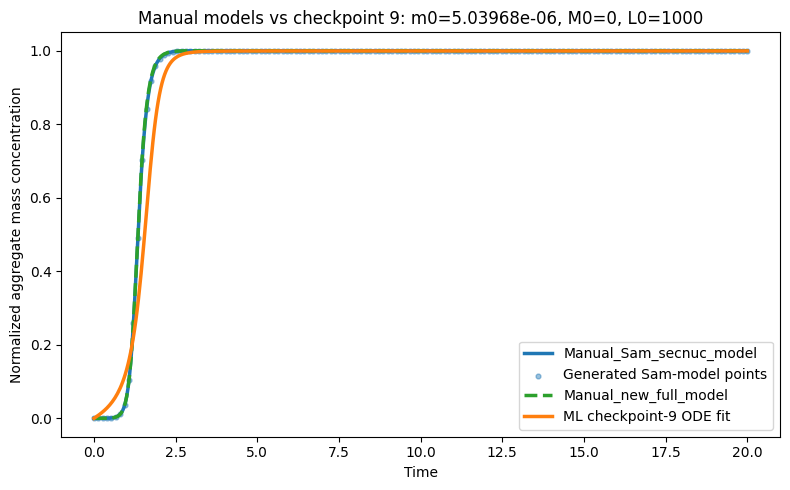

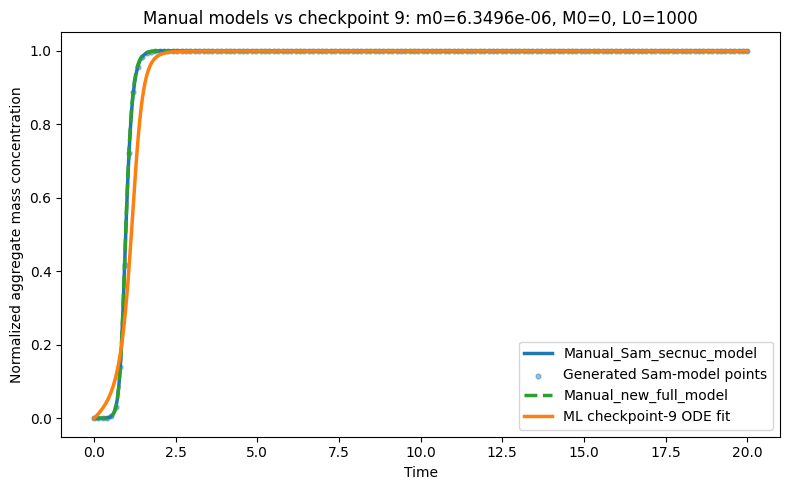

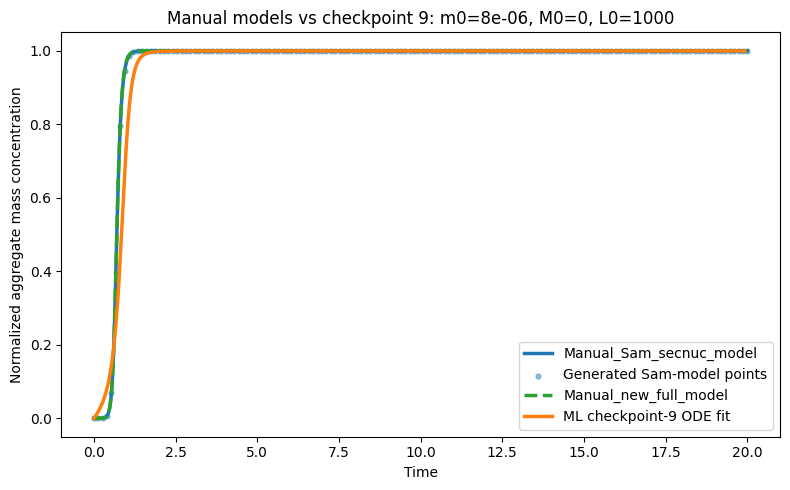

In [10]:
# Checkpoint 9 comparison on denser manual data with 10 configurations


def ML_checkpoint_9_normalized_time_ODE_rhs(concentration, tau, params, m0, L0, M0):
    """Numerical RHS from checkpoint_9/best_program.py."""
    c0, c1, c2, c3, c4, c5, c6, c7, c8 = params
    monomer = m0
    seed = M0
    concentration = float(np.asarray(concentration).reshape(-1)[0])

    plateau = c7
    capacity = plateau - concentration
    capacity_term = capacity ** (1 + c8 ** 2)

    primary = c0 ** 2 * monomer ** c1
    elongation = c2 ** 2 * (1 + c6 ** 2 * seed) * concentration
    secondary = c3 ** 2 * monomer ** c4 * concentration ** (1 + c5 ** 2)
    growth = primary + elongation + secondary
    return capacity_term * growth


def ML_checkpoint_9_normalized_time_ODE(X, c0, c1, c2, c3, c4, c5, c6, c7, c8):
    """Integrate checkpoint 9's discovered ODE curve by curve."""
    times, m0, L0, M0, groups = X
    times = np.asarray(times, dtype=float)
    m0 = np.asarray(m0, dtype=float)
    L0 = np.asarray(L0, dtype=float)
    M0 = np.asarray(M0, dtype=float)
    groups = np.rint(np.asarray(groups)).astype(int)
    params = (c0, c1, c2, c3, c4, c5, c6, c7, c8)
    y_pred = np.empty(times.shape[0], dtype=float)

    for g in np.unique(groups):
        idx = np.flatnonzero(groups == g)
        g_t = times[idx]
        g_m0 = float(m0[idx[0]])
        g_L0 = float(L0[idx[0]])
        g_M0 = float(M0[idx[0]])

        t_span = float(np.max(g_t) - np.min(g_t))
        tau = np.zeros_like(g_t, dtype=float) if t_span <= 0 else (g_t - np.min(g_t)) / t_span
        tau_unique, inverse = np.unique(tau, return_inverse=True)
        tau_eval = tau_unique if tau_unique[0] == 0.0 else np.concatenate(([0.0], tau_unique))

        # For these generated manual curves, the observed normalized state at t=0
        # is M0/(m0+M0). This matches the benchmark's observed[0] convention.
        initial_state = g_M0 / (g_m0 + g_M0) if (g_m0 + g_M0) > 0 else 0.0

        try:
            sol = odeint(
                lambda y, tt: ML_checkpoint_9_normalized_time_ODE_rhs(y, tt, params, g_m0, g_L0, g_M0),
                [initial_state],
                tau_eval,
                mxstep=1000,
                atol=1e-12,
                rtol=1e-9,
            ).reshape(-1)
            if tau_unique[0] != 0.0:
                sol = sol[1:]
            y_pred[idx] = sol[inverse]
        except Exception:
            y_pred[idx] = np.nan

    return y_pred


ML_checkpoint_9_normalized_time_ODE.param_names = ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8']


def make_dense_manual_model_data_for_checkpoint_9():
    """Generate denser manual-model data for 10 m0 configurations."""
    m0_values = np.geomspace(1e-6, 8e-6, 10)
    L0_values = [1000.0]
    M0_values = [0.0]
    kn, nc, k2, n2, kp = 1.0, 2.0, 1e10, 2.0, 3e7

    t_data = np.linspace(0, 20, 150)
    all_data = {}
    for m0_i in m0_values:
        for M0_i in M0_values:
            for L0_i in L0_values:
                name = f'm0:{m0_i}_M0:{M0_i}_L0:{L0_i}'
                y_i = Manual_Sam_secnuc_model(t_data, m0_i, L0_i, M0_i, kn, nc, k2, n2, kp)
                all_data[name + ' X'] = t_data
                all_data[name + ' Y'] = y_i

    return pd.DataFrame(all_data)


def run_multistart_basinhopping_fit(ML_model, initial_guess, data_df, scales=(1.0, 0.3, 3.0), niter=50):
    """Fit constants with basinhopping from multiple scaled starting points."""
    expected_params, model_param_names = _model_param_info(ML_model)
    if len(initial_guess) != expected_params:
        raise ValueError(f"Initial guess has {len(initial_guess)} parameters, but {expected_params} are expected.")

    all_t, all_m0, all_y, all_M0, all_L0, all_groups = [], [], [], [], [], []
    curve_idx = 0
    for col in data_df.columns:
        name_parts_dict = col_name_to_dict(col)
        if 'X' in col:
            all_t.append(data_df[col].values[~np.isnan(data_df[col].values)])
        elif 'Y' in col:
            vals = data_df[col].values
            mask = ~np.isnan(vals)
            y = vals[mask]
            all_y.append(y)
            all_m0.append(np.full_like(y, name_parts_dict['m0'], dtype=float))
            all_M0.append(np.full_like(y, name_parts_dict['M0'], dtype=float))
            all_L0.append(np.full_like(y, name_parts_dict['L0'], dtype=float))
            all_groups.append(np.full(y.shape, curve_idx, dtype=int))
            curve_idx += 1

    X = (
        np.concatenate(all_t),
        np.concatenate(all_m0),
        np.concatenate(all_L0),
        np.concatenate(all_M0),
        np.concatenate(all_groups),
    )
    y = np.concatenate(all_y)
    residual_scale = float(np.sqrt(np.var(y))) if np.var(y) > 0 else 1.0

    def objective(theta):
        try:
            prediction = ML_model(X, *theta)
        except Exception:
            return 1e12
        if prediction.shape != y.shape or not np.all(np.isfinite(prediction)):
            return 1e12
        residual = (prediction - y) / residual_scale
        return float(np.mean(residual ** 2))

    starts = []
    for scale in scales:
        candidate = initial_guess * float(scale)
        if not any(np.array_equal(candidate, existing) for existing in starts):
            starts.append(candidate)

    best_result = None
    best_loss = float('inf')
    minimizer_kwargs = {'method': 'Nelder-Mead'}
    for start in starts:
        result = opt.basinhopping(
            objective,
            start,
            niter=niter,
            T=1.0,
            stepsize=0.5,
            minimizer_kwargs=minimizer_kwargs,
        )
        loss = objective(result.x)
        if loss < best_loss:
            best_loss = loss
            best_result = result

    if best_result is None:
        raise RuntimeError('No basinhopping fit succeeded.')

    return best_result.x, best_loss, model_param_names, data_df


dense_checkpoint_9_data_df = make_dense_manual_model_data_for_checkpoint_9()
ML_model = ML_checkpoint_9_normalized_time_ODE
initial_guess_checkpoint_9 = np.array([0.3, 0.5, 0.5, 0.8, 0.5, 1.0, 0.5, 1.0, 0.0])

popt_checkpoint_9, err_checkpoint_9, param_names_checkpoint_9, dense_checkpoint_9_data_df = run_multistart_basinhopping_fit(
    ML_model,
    initial_guess_checkpoint_9,
    dense_checkpoint_9_data_df,
    scales=(1.0, 0.3, 3.0),
    niter=50,
)

def plot_manual_models_and_checkpoint_9_by_configuration(data_df, ML_model, popt, save_prefix=None):
    """One plot per condition: both manual model curves, generated points, and checkpoint-9 ODE curve."""
    conditions = [i.strip(' Y') for i in data_df.columns if 'Y' in i]
    kn, nc, k2, n2, kp = 1.0, 2.0, 1e10, 2.0, 3e7

    # Turn off fragmentation, saturation, and inhibition in the full manual model
    # so it is comparable to the simpler secondary-nucleation setup.
    km = 0.0
    KE = KP = KS = 1e6
    cd = 0.0
    KIE = KIP = KIS = KIM = 1.0

    for cond in conditions:
        t_raw = data_df[cond + ' X'].values
        y_raw = data_df[cond + ' Y'].values
        mask = ~(np.isnan(t_raw) | np.isnan(y_raw))
        t_i, y_i = t_raw[mask], y_raw[mask]

        name_parts_dict = col_name_to_dict(cond)
        m0 = float(name_parts_dict['m0'])
        M0 = float(name_parts_dict['M0'])
        L0 = float(name_parts_dict['L0'])

        t_grid = np.linspace(t_i.min(), t_i.max(), 500)
        y_manual_sam = Manual_Sam_secnuc_model(t_grid, m0, L0, M0, kn, nc, k2, n2, kp)
        y_manual_full = Manual_new_full_model(
            t_grid, m0, L0, M0, kn, nc, k2, n2, kp,
            km, KE, KP, KS, cd, KIE, KIP, KIS, KIM,
        )
        X_grid = (t_grid,
                  np.full_like(t_grid, m0),
                  np.full_like(t_grid, L0),
                  np.full_like(t_grid, M0),
                  np.zeros_like(t_grid, dtype=int))
        y_ml = ML_model(X_grid, *popt)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(t_grid, y_manual_sam, linewidth=2.5, label='Manual_Sam_secnuc_model', color='tab:blue')
        ax.scatter(t_i, y_i, s=12, alpha=0.45, label='Generated Sam-model points', color='tab:blue')
        ax.plot(t_grid, y_manual_full, linewidth=2.5, linestyle='--', label='Manual_new_full_model', color='tab:green')
        ax.plot(t_grid, y_ml, linewidth=2.5, label='ML checkpoint-9 ODE fit', color='tab:orange')
        ax.set_xlabel('Time')
        ax.set_ylabel('Normalized aggregate mass concentration')
        ax.set_title(f'Manual models vs checkpoint 9: m0={m0:g}, M0={M0:g}, L0={L0:g}')
        ax.legend()
        fig.tight_layout()

        if save_prefix:
            safe_cond = cond.replace(':', '-').replace('.', 'p').replace(' ', '_')
            fig.savefig(f'{save_prefix}_{safe_cond}.png', dpi=300)
        else:
            plt.show()


print(f"Checkpoint 9 basinhopping scaled residual loss: {err_checkpoint_9}")
print("Checkpoint 9 fitted parameters:\n" + "\n".join(
    f"{name}: {value:.2e}" for name, value in zip(param_names_checkpoint_9, popt_checkpoint_9)
))
plot_manual_models_and_checkpoint_9_by_configuration(dense_checkpoint_9_data_df, ML_model, popt_checkpoint_9)


/tmp/ipykernel_27933/1459893390.py:62: RuntimeWarning: overflow encountered in scalar power
  secondary = c3 ** 2 * monomer ** c4 * concentration * gate
/tmp/ipykernel_27933/1459893390.py:62: RuntimeWarning: invalid value encountered in scalar multiply
  secondary = c3 ** 2 * monomer ** c4 * concentration * gate
/tmp/ipykernel_27933/1459893390.py:62: RuntimeWarning: overflow encountered in scalar multiply
  secondary = c3 ** 2 * monomer ** c4 * concentration * gate
/tmp/ipykernel_27933/1459893390.py:105: ODEintWarning: Repeated convergence failures (perhaps bad Jacobian or tolerances). Run with full_output = 1 to get quantitative information.
  sol = odeint(
/tmp/ipykernel_27933/1459893390.py:64: RuntimeWarning: overflow encountered in scalar multiply
  return capacity * growth


Checkpoint 24 basinhopping scaled residual loss: 0.0002916246762874694
Checkpoint 24 fitted parameters:
c0: 1.15e+01
c1: 7.67e-01
c2: -2.30e-01
c3: 1.07e+05
c4: 1.49e+00
c5: -1.26e+08
c6: -1.41e+05
c7: 9.98e-01
c8: 2.66e+07


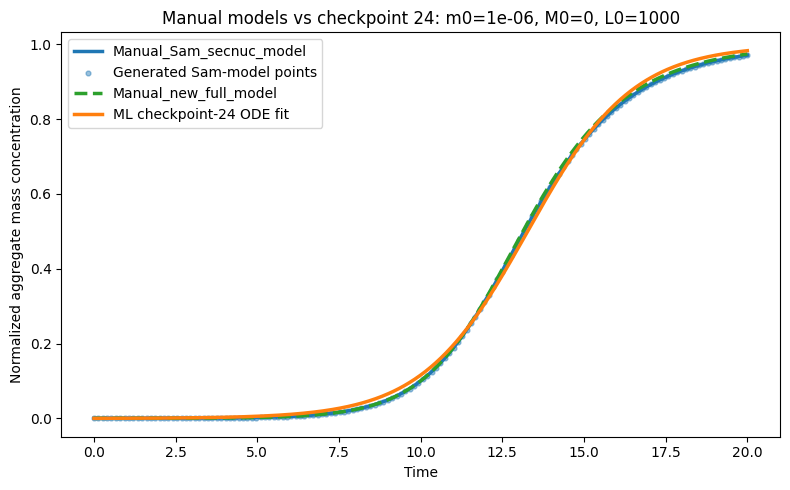

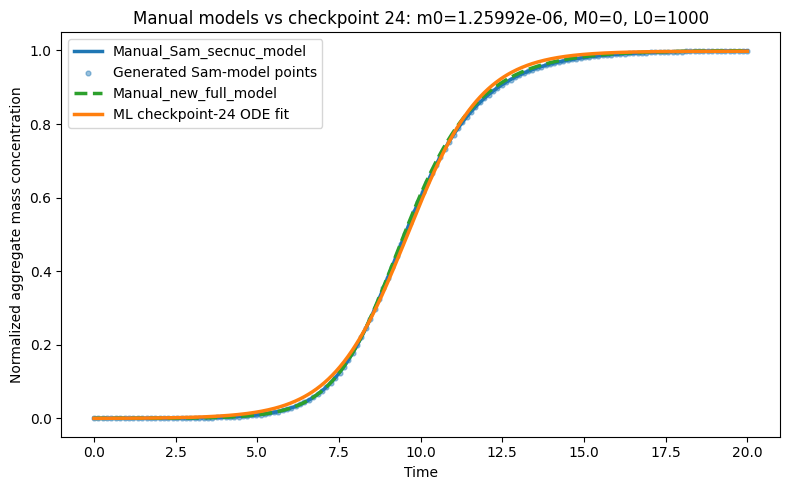

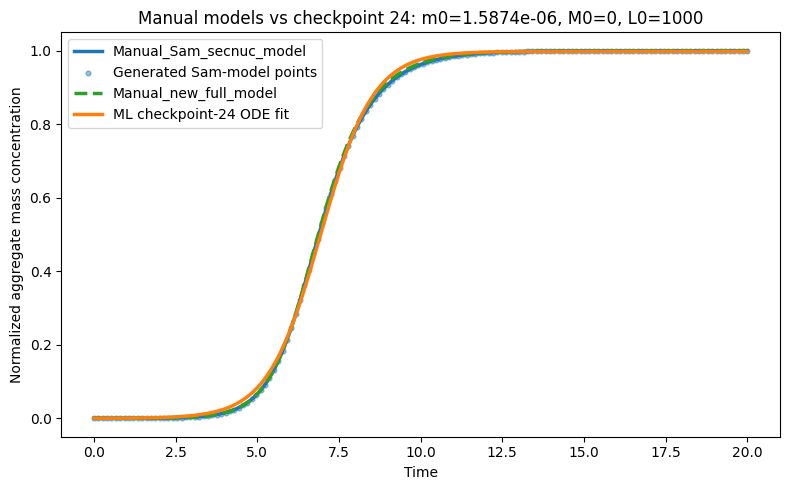

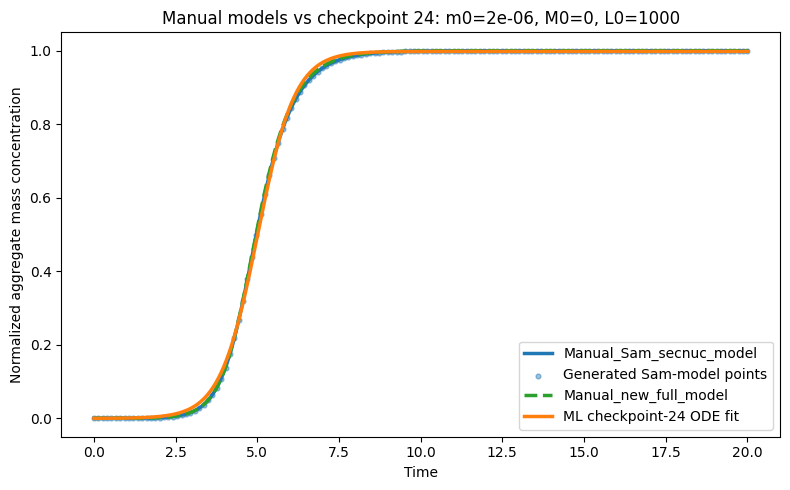

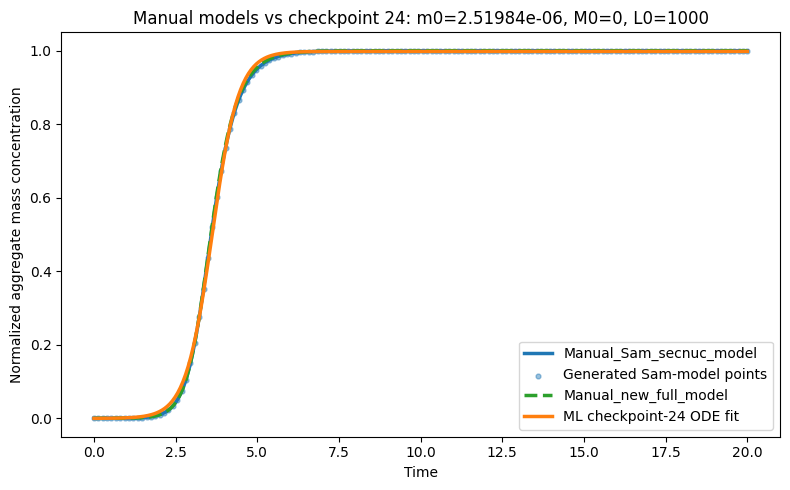

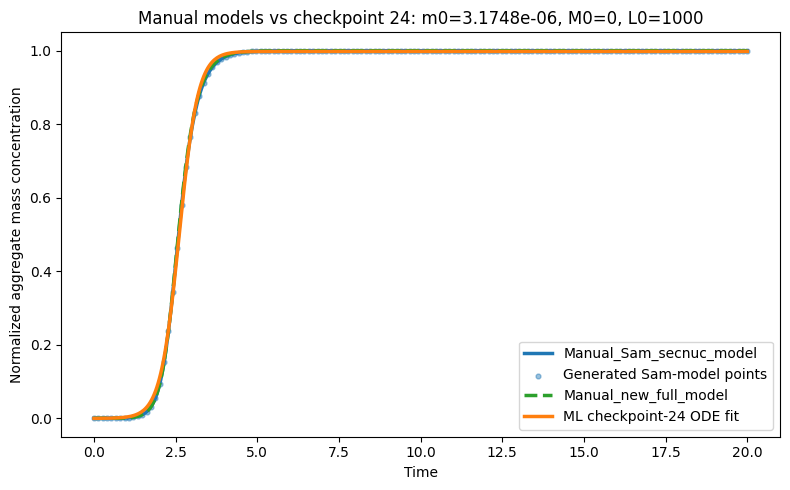

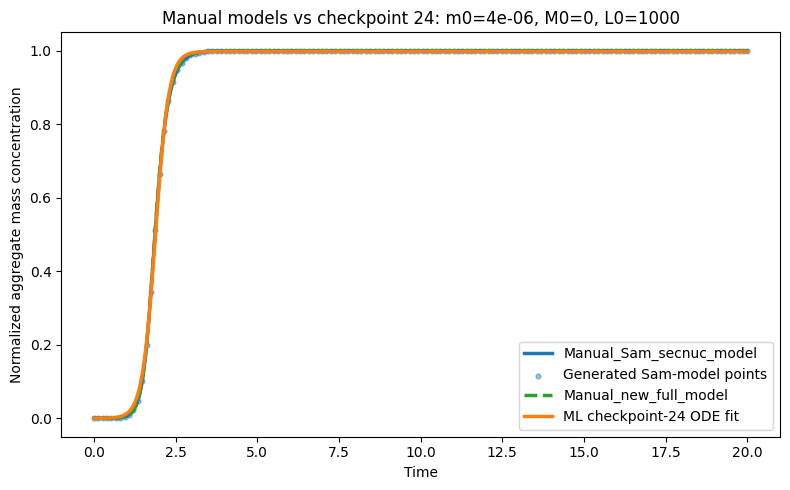

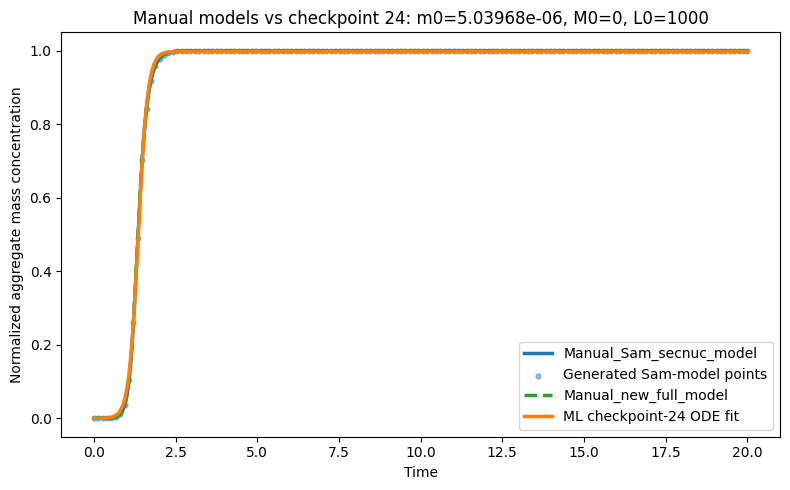

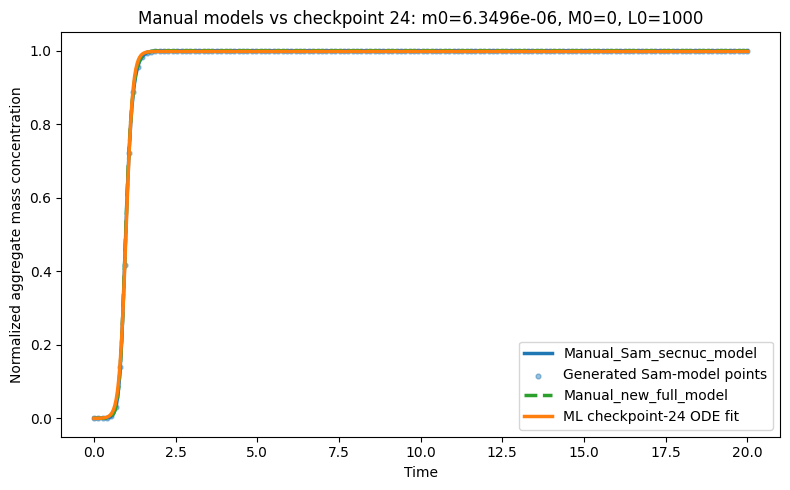

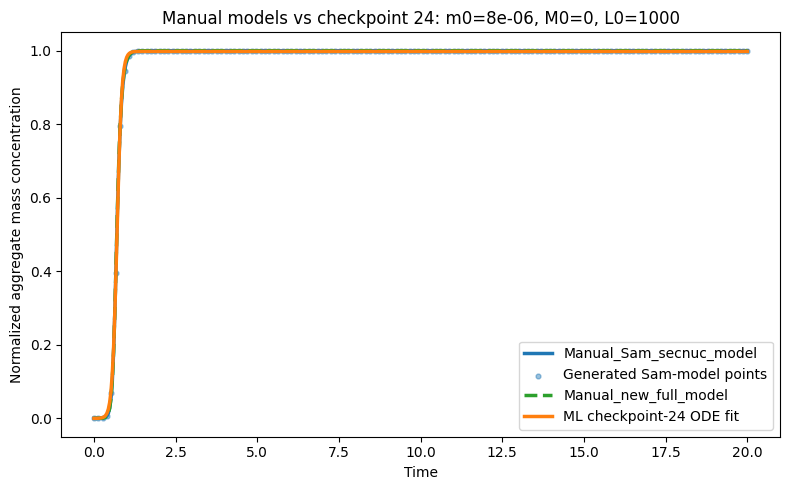

In [9]:
# Checkpoint 24 comparison on denser manual data with 10 configurations


def make_dense_manual_model_data(n_configs=10, n_timepoints=150):
    """Generate dense synthetic ground-truth data from Manual_Sam_secnuc_model."""
    m0_values = np.geomspace(1e-6, 8e-6, n_configs)
    L0_values = [1000.0]
    M0_values = [0.0]
    kn, nc, k2, n2, kp = 1.0, 2.0, 1e10, 2.0, 3e7

    t_data = np.linspace(0, 20, n_timepoints)
    all_data = {}
    for m0_i in m0_values:
        for M0_i in M0_values:
            for L0_i in L0_values:
                name = f'm0:{m0_i}_M0:{M0_i}_L0:{L0_i}'
                y_i = Manual_Sam_secnuc_model(t_data, m0_i, L0_i, M0_i, kn, nc, k2, n2, kp)
                all_data[name + ' X'] = t_data
                all_data[name + ' Y'] = y_i

    return pd.DataFrame(all_data)


def run_multistart_basinhopping_fit_from_dataframe(ML_model, initial_guess, data_df, scales=(1.0, 0.3, 3.0), niter=50):
    """Fit constants with basinhopping from multiple scaled starting points."""
    expected_params, model_param_names = _model_param_info(ML_model)
    if len(initial_guess) != expected_params:
        raise ValueError(f"Initial guess has {len(initial_guess)} parameters, but {expected_params} are expected.")

    all_t, all_m0, all_y, all_M0, all_L0, all_groups = [], [], [], [], [], []
    curve_idx = 0
    for col in data_df.columns:
        name_parts_dict = col_name_to_dict(col)
        if 'X' in col:
            all_t.append(data_df[col].values[~np.isnan(data_df[col].values)])
        elif 'Y' in col:
            vals = data_df[col].values
            mask = ~np.isnan(vals)
            y = vals[mask]
            all_y.append(y)
            all_m0.append(np.full_like(y, name_parts_dict['m0'], dtype=float))
            all_M0.append(np.full_like(y, name_parts_dict['M0'], dtype=float))
            all_L0.append(np.full_like(y, name_parts_dict['L0'], dtype=float))
            all_groups.append(np.full(y.shape, curve_idx, dtype=int))
            curve_idx += 1

    X = (
        np.concatenate(all_t),
        np.concatenate(all_m0),
        np.concatenate(all_L0),
        np.concatenate(all_M0),
        np.concatenate(all_groups),
    )
    y = np.concatenate(all_y)
    residual_scale = float(np.sqrt(np.var(y))) if np.var(y) > 0 else 1.0

    def objective(theta):
        try:
            prediction = ML_model(X, *theta)
        except Exception:
            return 1e12
        if prediction.shape != y.shape or not np.all(np.isfinite(prediction)):
            return 1e12
        residual = (prediction - y) / residual_scale
        return float(np.mean(residual ** 2))

    starts = []
    for scale in scales:
        candidate = initial_guess * float(scale)
        if not any(np.array_equal(candidate, existing) for existing in starts):
            starts.append(candidate)

    best_result = None
    best_loss = float('inf')
    minimizer_kwargs = {'method': 'Nelder-Mead'}
    for start in starts:
        result = opt.basinhopping(
            objective,
            start,
            niter=niter,
            T=1.0,
            stepsize=0.5,
            minimizer_kwargs=minimizer_kwargs,
        )
        loss = objective(result.x)
        if loss < best_loss:
            best_loss = loss
            best_result = result

    if best_result is None:
        raise RuntimeError('No basinhopping fit succeeded.')

    return best_result.x, best_loss, model_param_names, data_df


def plot_manual_model_and_ml_by_configuration(data_df, ML_model, popt, save_prefix=None, ml_label='ML checkpoint-24 ODE fit'):
    """One plot per condition: both manual model curves, generated points, and ML ODE curve."""
    conditions = [col.removesuffix(' Y') for col in data_df.columns if col.endswith(' Y')]
    kn, nc, k2, n2, kp = 1.0, 2.0, 1e10, 2.0, 3e7

    # Turn off fragmentation, saturation, and inhibition in the full manual model
    # so it is comparable to the simpler secondary-nucleation setup.
    km = 0.0
    KE = KP = KS = 1e6
    cd = 0.0
    KIE = KIP = KIS = KIM = 1.0

    for cond in conditions:
        t_raw = data_df[cond + ' X'].values
        y_raw = data_df[cond + ' Y'].values
        mask = ~(np.isnan(t_raw) | np.isnan(y_raw))
        t_i, y_i = t_raw[mask], y_raw[mask]

        name_parts_dict = col_name_to_dict(cond)
        m0 = float(name_parts_dict['m0'])
        M0 = float(name_parts_dict['M0'])
        L0 = float(name_parts_dict['L0'])

        t_grid = np.linspace(t_i.min(), t_i.max(), 500)
        y_manual_sam = Manual_Sam_secnuc_model(t_grid, m0, L0, M0, kn, nc, k2, n2, kp)
        y_manual_full = Manual_new_full_model(
            t_grid, m0, L0, M0, kn, nc, k2, n2, kp,
            km, KE, KP, KS, cd, KIE, KIP, KIS, KIM,
        )
        X_grid = (t_grid,
                  np.full_like(t_grid, m0),
                  np.full_like(t_grid, L0),
                  np.full_like(t_grid, M0),
                  np.zeros_like(t_grid, dtype=int))
        y_ml = ML_model(X_grid, *popt)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(t_grid, y_manual_sam, linewidth=2.5, label='Manual_Sam_secnuc_model', color='tab:blue')
        ax.scatter(t_i, y_i, s=12, alpha=0.45, label='Generated Sam-model points', color='tab:blue')
        ax.plot(t_grid, y_manual_full, linewidth=2.5, linestyle='--', label='Manual_new_full_model', color='tab:green')
        ax.plot(t_grid, y_ml, linewidth=2.5, label=ml_label, color='tab:orange')
        ax.set_xlabel('Time')
        ax.set_ylabel('Normalized aggregate mass concentration')
        ax.set_title(f'Manual models vs checkpoint 24: m0={m0:g}, M0={M0:g}, L0={L0:g}')
        ax.legend()
        fig.tight_layout()

        if save_prefix:
            safe_cond = cond.replace(':', '-').replace('.', 'p').replace(' ', '_')
            fig.savefig(f'{save_prefix}_{safe_cond}.png', dpi=300)
        else:
            plt.show()


dense_checkpoint_24_data_df = make_dense_manual_model_data(n_configs=10, n_timepoints=150)
ML_model_checkpoint_24 = ML_checkpoint_24_normalized_time_ODE
initial_guess_checkpoint_24 = np.array([0.3, 0.5, 0.5, 0.8, 0.5, 0.3, 0.5, 1.0, 2.0])

popt_checkpoint_24, err_checkpoint_24, param_names_checkpoint_24, dense_checkpoint_24_data_df = run_multistart_basinhopping_fit_from_dataframe(
    ML_model_checkpoint_24,
    initial_guess_checkpoint_24,
    dense_checkpoint_24_data_df,
    scales=(1.0, 0.3, 3.0),
    niter=50,
)

print(f"Checkpoint 24 basinhopping scaled residual loss: {err_checkpoint_24}")
print("Checkpoint 24 fitted parameters:\n" + "\n".join(
    f"{name}: {value:.2e}" for name, value in zip(param_names_checkpoint_24, popt_checkpoint_24)
))
plot_manual_model_and_ml_by_configuration(dense_checkpoint_24_data_df, ML_model_checkpoint_24, popt_checkpoint_24)


Plotting nonzero-M0 cases using checkpoint-24 parameters fit from M0=0 data.


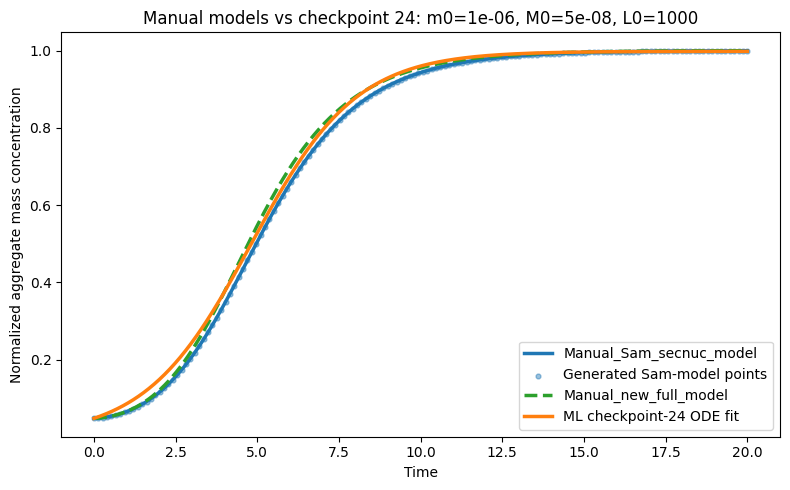

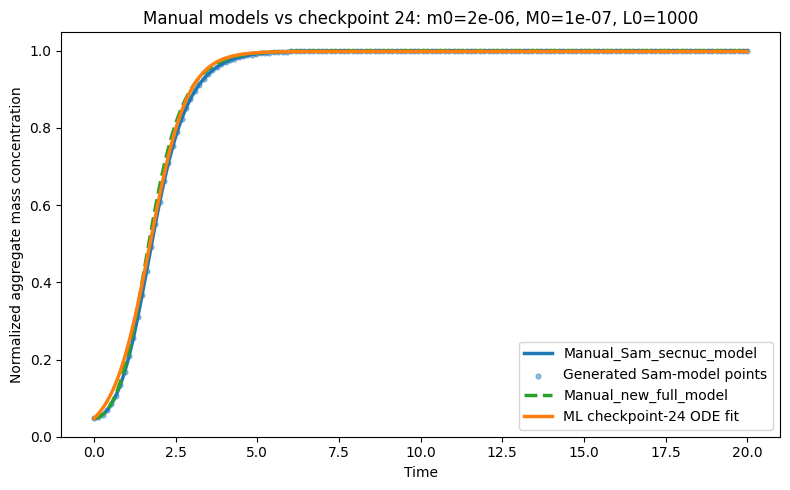

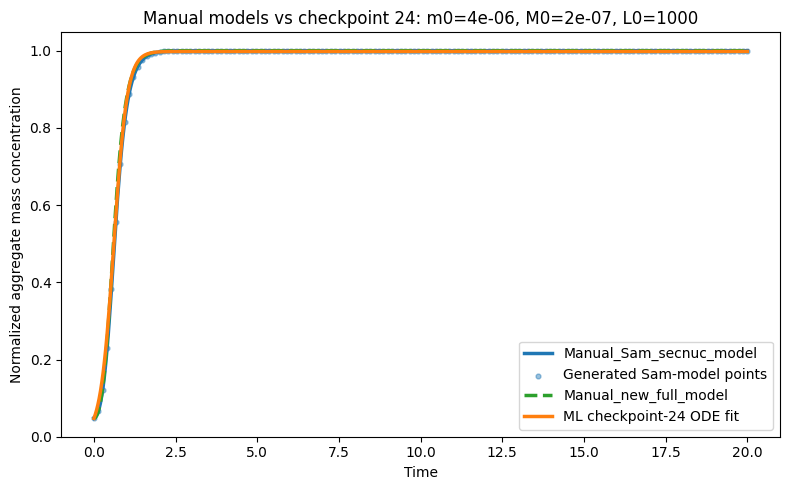

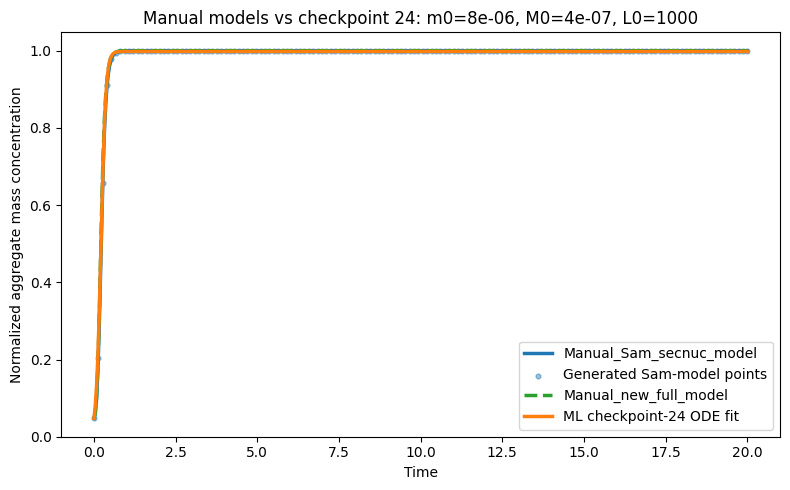

In [ ]:
# Four checkpoint-24 comparison plots with nonzero initial aggregate mass (M0)
nonzero_M0_data = {}
nonzero_M0_m0_values = np.geomspace(1e-6, 8e-6, 4)
nonzero_M0_t_data = np.linspace(0, 20, 150)
kn, nc, k2, n2, kp = 1.0, 2.0, 1e10, 2.0, 3e7
L0 = 1000.0

for m0_i in nonzero_M0_m0_values:
    M0_i = 0.05 * m0_i
    name = f'm0:{m0_i}_M0:{M0_i}_L0:{L0}'
    y_i = Manual_Sam_secnuc_model(nonzero_M0_t_data, m0_i, L0, M0_i, kn, nc, k2, n2, kp)
    nonzero_M0_data[name + ' X'] = nonzero_M0_t_data
    nonzero_M0_data[name + ' Y'] = y_i

nonzero_M0_checkpoint_24_data_df = pd.DataFrame(nonzero_M0_data)
print('Plotting nonzero-M0 cases using checkpoint-24 parameters fit from M0=0 data.')
plot_manual_model_and_ml_by_configuration(
    nonzero_M0_checkpoint_24_data_df,
    ML_model_checkpoint_24,
    popt_checkpoint_24,
)